In [2]:
# Cell: W&B interactive login (safe)
import getpass, wandb, os

key = getpass.getpass("Enter your WANDB API key (it will be hidden): ")
success = wandb.login(key=key)
print("wandb login success:", success)

# If you want spawned subprocesses to also see the key during this kernel session:
if success:
    os.environ["WANDB_API_KEY"] = key

# wipe the key variable from memory
key = None
del key


Enter your WANDB API key (it will be hidden):  ········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/garima/.netrc


wandb login success: True


In [13]:
# Cell: transforms and DataLoader creation

# First load the raw datasets and compute mean/std
train_subset_raw, val_subset_raw, test_raw, mean_pix, std_pix = load_fashion_data(root="./data", val_ratio=0.1, download=True)

# Define transforms
train_transform = transforms.Compose([
    # light augmentations only for training
    transforms.RandomCrop(28, padding=4),
    transforms.RandomRotation(degrees=10, interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),  # converts to [0,1]
    transforms.Normalize(mean=[mean_pix], std=[std_pix]),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean_pix], std=[std_pix]),
])

# Wrap raw subsets with our custom dataset wrapper
train_dataset = FashionMNISTDataset(train_subset_raw, transform=train_transform)
val_dataset = FashionMNISTDataset(val_subset_raw, transform=eval_transform)
test_dataset = FashionMNISTDataset(test_raw, transform=eval_transform)

# DataLoader parameters
BATCH_SIZE = 128
loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=loader_generator, drop_last=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataset sizes -> train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}")


Computed dataset mean=0.286041, std=0.353024
Dataset sizes -> train: 54000, val: 6000, test: 10000


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import random
import matplotlib.pyplot as plt
import wandb
import os

# --- Global Constants and Setup ---
NUM_CLASSES = 10
SEED = 101
DATA_DIR = './data'
FASHION_MEAN = (0.2860,) 
FASHION_STD = (0.3530,)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMAIL_USERNAME = "garima.mittal"

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

def load_fashion_data(data_dir=DATA_DIR, val_ratio=0.1):
    """
    Loads Fashion-MNIST and splits the original training set into train/validation (e.g., 90/10 ratio).
    Crucially, it loads the raw data (PIL Images) without initial transforms.
    """
    # Load without any transforms initially (returns PIL Images)
    full_train_dataset = datasets.FashionMNIST(
        root=data_dir, train=True, download=True, transform=None
    )
    test_dataset = datasets.FashionMNIST(
        root=data_dir, train=False, download=True, transform=None
    )

    train_size = int((1.0 - val_ratio) * len(full_train_dataset))
    val_size = len(full_train_dataset) - train_size
    
    # Ensures no overlap or data leakage
    train_dataset, val_dataset = random_split(
        full_train_dataset, 
        [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )
    
    return train_dataset, val_dataset, test_dataset

class FashionMNISTDataset(Dataset):
    """
    Custom Dataset class that returns tuples (image, class_label, ink_target).
    Applies ToTensor and Normalize *inside* the class.
    """
    def __init__(self, subset, is_train=False):
        self.subset = subset
        
        # Define Transforms (includes ToTensor and Normalize)
        if is_train:
            # Light augmentations (e.g., random crop, small rotation) for training set only
            self.transform = transforms.Compose([
                transforms.RandomRotation(degrees=5), 
                transforms.RandomCrop(28, padding=4), 
                transforms.ToTensor(), # Must be here, applied to PIL Image
                transforms.Normalize(FASHION_MEAN, FASHION_STD) 
            ])
        else:
            # Validation and test sets unaltered
            self.transform = transforms.Compose([
                transforms.ToTensor(), # Must be here
                transforms.Normalize(FASHION_MEAN, FASHION_STD) 
            ])

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        # image_raw is a PIL Image
        if isinstance(self.subset, torch.utils.data.Subset):
             image_raw, class_label = self.subset.dataset[self.subset.indices[idx]]
        else:
             image_raw, class_label = self.subset[idx]

        # ink_target: calculated on the [0, 1] tensor for normalized pixel intensity
        ink_tensor_0_1 = transforms.ToTensor()(image_raw)
        ink_target = ink_tensor_0_1.mean().item()
        ink_target = torch.tensor(ink_target, dtype=torch.float32).unsqueeze(0)
        
        # image: normalized tensor
        image = self.transform(image_raw)
        class_label = torch.tensor(class_label, dtype=torch.long)

        return image, class_label, ink_target

In [27]:
# The MultiTaskCNN and joint_loss_fn must be defined globally for the training part.

class MultiTaskCNN(nn.Module):
    """
    Multi-Task CNN with shared convolutional backbone and two separate heads.
    """
    def __init__(self, num_classes=NUM_CLASSES, dropout_rate=0.3):
        super(MultiTaskCNN, self).__init__()
        self.device = DEVICE

        # Shared Convolutional Backbone: 2-3 Conv-BatchNorm-ReLU-Pool blocks
        self.backbone = nn.Sequential(
            # Block 1 (Output: 32 channels, 14x14)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            nn.Dropout(dropout_rate),

            # Block 2 (Output: 64 channels, 7x7)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            nn.Dropout(dropout_rate),

            # Block 3 (Output: 128 channels, 7x7) - Final features
            nn.Conv2d(64, 128, kernel_size=3, padding=1), 
            nn.ReLU(),
        )
        
        self.flatten_size = 128 * 7 * 7
        
        # Classification Head: outputs logits [B, 10]
        self.classification_head = nn.Sequential(
            nn.Linear(self.flatten_size, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes)
        )
        
        # Regression Head: outputs scalar values [B, 1]
        self.regression_head = nn.Sequential(
            nn.Linear(self.flatten_size, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        """Outputs classification logits and regression predictions."""
        shared_features = self.backbone(x)
        flattened_features = shared_features.view(x.size(0), -1)

        cls_logits = self.classification_head(flattened_features)
        reg_pred = self.regression_head(flattened_features)
        
        return cls_logits, reg_pred, shared_features 

def joint_loss_fn(cls_logits, reg_pred, cls_target, reg_target, lambda1, lambda2):
    """
    Calculates the total joint loss: L_total = lambda1*L_CE + lambda2*L_MSE.
    """
    L_classification = nn.CrossEntropyLoss()(cls_logits, cls_target)
    L_regression = nn.MSELoss()(reg_pred, reg_target)
    
    total_loss = lambda1 * L_classification + lambda2 * L_regression
    
    return total_loss, L_classification, L_regression

def calculate_metrics(cls_logits, reg_pred, cls_target, reg_target):
    """Calculates classification accuracy, MAE, and RMSE."""
    _, predicted_classes = torch.max(cls_logits, 1)
    correct = (predicted_classes == cls_target).sum().item()
    accuracy = correct / cls_target.size(0)
    
    mae = torch.mean(torch.abs(reg_pred.squeeze() - reg_target.squeeze())).item()
    rmse = torch.sqrt(torch.mean((reg_pred.squeeze() - reg_target.squeeze())**2)).item()
    
    return accuracy, mae, rmse

In [28]:
# The train_and_validate and evaluate_on_test functions.

def train_and_validate(model, train_loader, val_loader, optimizer, config):
    """
    Runs the training process for one configuration and logs all metrics to wandb.
    Saves best models based on validation accuracy and RMSE.
    """
    model.to(DEVICE)
    best_val_acc = 0.0
    best_val_rmse = float('inf')
    
    # Mandatory wandb initialization and logging configuration
    wandb.init(project="SMAI_A4_MultiTaskCNN", config=config, name=config['run_name'])
    
    for epoch in range(config['epochs']):
        # --- Training Phase ---
        model.train()
        train_metrics = {'total_loss': 0, 'ce_loss': 0, 'mse_loss': 0}
        
        for images, cls_targets, reg_targets in train_loader:
            images, cls_targets, reg_targets = images.to(DEVICE), cls_targets.to(DEVICE), reg_targets.to(DEVICE)
            
            cls_logits, reg_pred, _ = model(images)
            total_loss, ce_loss, mse_loss = joint_loss_fn(
                cls_logits, reg_pred, cls_targets, reg_targets, config['lambda1'], config['lambda2']
            )
            
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()
            
            train_metrics['total_loss'] += total_loss.item()
            train_metrics['ce_loss'] += ce_loss.item()
            train_metrics['mse_loss'] += mse_loss.item()

        # Log training loss curves
        wandb.log({
            "epoch": epoch,
            "train/total_loss": train_metrics['total_loss'] / len(train_loader),
            "train/ce_loss": train_metrics['ce_loss'] / len(train_loader),
            "train/mse_loss": train_metrics['mse_loss'] / len(train_loader),
        })

        # --- Validation Phase ---
        model.eval()
        val_metrics = {'total_acc': 0, 'total_mae': 0, 'total_rmse': 0, 'total_val_loss': 0}
        total_samples = 0
        
        with torch.no_grad():
            for images, cls_targets, reg_targets in val_loader:
                images, cls_targets, reg_targets = images.to(DEVICE), cls_targets.to(DEVICE), reg_targets.to(DEVICE)
                
                cls_logits, reg_pred, _ = model(images)
                
                total_loss, _, _ = joint_loss_fn(
                    cls_logits, reg_pred, cls_targets, reg_targets, config['lambda1'], config['lambda2']
                )

                acc, mae, rmse = calculate_metrics(cls_logits, reg_pred, cls_targets, reg_targets)
                
                batch_size = cls_targets.size(0)
                val_metrics['total_acc'] += acc * batch_size
                val_metrics['total_mae'] += mae * batch_size
                val_metrics['total_rmse'] += rmse * batch_size
                val_metrics['total_val_loss'] += total_loss.item()
                total_samples += batch_size

        # Calculate and log validation metrics
        avg_val_acc = val_metrics['total_acc'] / total_samples
        avg_val_rmse = val_metrics['total_rmse'] / total_samples
        
        wandb.log({
            "epoch": epoch,
            "val/total_loss": val_metrics['total_val_loss'] / len(val_loader),
            "val/accuracy": avg_val_acc,
            "val/mae": val_metrics['total_mae'] / total_samples,
            "val/rmse": avg_val_rmse,
        })
        
        # Model selection: Save best checkpoint based on validation accuracy and RMSE
        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            torch.save(model.state_dict(), f"best_acc_model_{config['run_name']}.pth")
            wandb.run.summary["best_val_acc"] = best_val_acc
            
        if avg_val_rmse < best_val_rmse:
            best_val_rmse = avg_val_rmse
            torch.save(model.state_dict(), f"best_rmse_model_{config['run_name']}.pth")
            wandb.run.summary["best_val_rmse"] = best_val_rmse
            
    wandb.finish()
    
    return best_val_acc, best_val_rmse

def evaluate_on_test(model_path, config, test_loader):
    """Evaluates a saved model on the test set."""
    model = MultiTaskCNN(dropout_rate=config['dropout_rate']).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()
    
    test_metrics = {'total_acc': 0, 'total_mae': 0, 'total_rmse': 0}
    total_samples = 0
    
    with torch.no_grad():
        for images, cls_targets, reg_targets in test_loader:
            images, cls_targets, reg_targets = images.to(DEVICE), cls_targets.to(DEVICE), reg_targets.to(DEVICE)
            
            cls_logits, reg_pred, _ = model(images)
            acc, mae, rmse = calculate_metrics(cls_logits, reg_pred, cls_targets, reg_targets)
            
            batch_size = cls_targets.size(0)
            test_metrics['total_acc'] += acc * batch_size
            test_metrics['total_mae'] += mae * batch_size
            test_metrics['total_rmse'] += rmse * batch_size
            total_samples += batch_size
            
    final_acc = test_metrics['total_acc'] / total_samples
    final_mae = test_metrics['total_mae'] / total_samples
    final_rmse = test_metrics['total_rmse'] / total_samples
    
    # Log final test performance
    wandb.init(project="SMAI_A4_MultiTaskCNN_garima", config=config, name=f"Test_{config['run_name']}", reinit=True)
    wandb.log({
        "test/final_accuracy": final_acc,
        "test/final_mae": final_mae,
        "test/final_rmse": final_rmse,
    })
    wandb.finish()
    
    return final_acc, final_mae, final_rmse

In [29]:
# The visualize_feature_maps function and the main execution block.

def visualize_feature_maps(model, test_dataset, indices, email_username):
    """
    Extracts and visualizes intermediate feature maps after each convolutional block.
    (FIXED: Corrected access to raw data for visualization.)
    """
    print(f"\n--- Starting Feature Map Visualization for {len(indices)} Images ---")
    
    # Layers to hook
    hook_layers = {
        'Block_1_ReLU': model.backbone[2],
        'Block_2_ReLU': model.backbone[7],
        'Block_3_ReLU': model.backbone[11]
    }
    
    feature_maps = {}
    hook_handles = []

    def hook_fn(module, input, output, name):
        feature_maps[name] = output.detach().cpu()

    # Register hooks
    for name, layer in hook_layers.items():
        handle = layer.register_forward_hook(lambda m, i, o, name=name: hook_fn(m, i, o, name))
        hook_handles.append(handle)

    model.eval()
    
    for idx in indices:
        # Get normalized image (tensor) from the custom dataset
        image, _, _ = test_dataset[idx] 
        
        # --- FIX APPLIED HERE: Direct access to the raw PIL image/label from the subset ---
        # test_dataset.subset is the raw FashionMNIST object.
        image_raw_pil, _ = test_dataset.subset[idx] 

        image_tensor = image.unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            _ = model(image_tensor) # Trigger the forward pass and hooks

        # Denormalize image for display (0-1 range)
        img_denorm = transforms.ToTensor()(image_raw_pil).squeeze().numpy()
        
        # Display the original image
        plt.figure(figsize=(2, 2))
        plt.imshow(img_denorm, cmap='gray')
        plt.title(f"Test Image {idx} (Original)")
        plt.axis('off')
        
        # Add username to plot
        plt.text(0.95, 0.95, email_username, ha='right', va='top', transform=plt.gcf().transFigure, fontsize=8, color='gray', alpha=0.7)
        plt.show()

        # Display feature maps
        for name, fm_tensor in feature_maps.items():
            fm = fm_tensor.squeeze(0)
            display_count = min(fm.size(0), 8)
            
            fig, axes = plt.subplots(1, display_count, figsize=(2 * display_count, 2))
            fig.suptitle(f"Image {idx}: {name} Feature Maps", fontsize=10)
            
            for i in range(display_count):
                ax = axes[i] if display_count > 1 else axes
                ax.imshow(fm[i].numpy(), cmap='viridis')
                ax.set_title(f'Ch {i+1}', fontsize=8)
                ax.axis('off')

            plt.text(0.95, 0.95, email_username, ha='right', va='top', transform=plt.gcf().transFigure, fontsize=8, color='gray', alpha=0.7)
            
            plt.tight_layout(rect=[0, 0, 1, 0.9])
            plt.show()
            
        feature_maps.clear()

    # Remove hooks
    for handle in hook_handles:
        handle.remove()

 

In [30]:
if __name__ == '__main__':
    # Define hyperparameter exploration configs (5 distinct runs)
    RUN_CONFIGS = [
        # 1. Baseline: lambda1=1, lambda2=1
        {'run_name': 'Run_1_Baseline_1:1', 'learning_rate': 1e-3, 'dropout_rate': 0.3, 'optimizer_choice': 'Adam', 'lambda1': 1.0, 'lambda2': 1.0, 'epochs': 15, 'batch_size': 128},
        
        # 2. Classification Weighted: lambda1=2, lambda2=1 
        {'run_name': 'Run_2_Cls_Weighted_2:1', 'learning_rate': 1e-3, 'dropout_rate': 0.3, 'optimizer_choice': 'Adam', 'lambda1': 2.0, 'lambda2': 1.0, 'epochs': 15, 'batch_size': 128},
        
        # 3. Regression Weighted: lambda1=1, lambda2=2 
        {'run_name': 'Run_3_Reg_Weighted_1:2', 'learning_rate': 1e-3, 'dropout_rate': 0.3, 'optimizer_choice': 'Adam', 'lambda1': 1.0, 'lambda2': 2.0, 'epochs': 15, 'batch_size': 128},
        
        # 4. Explore Optimizer & LR
        {'run_name': 'Run_4_SGD_LowLR_1:1', 'learning_rate': 1e-4, 'dropout_rate': 0.3, 'optimizer_choice': 'SGD', 'lambda1': 1.0, 'lambda2': 1.0, 'epochs': 15, 'batch_size': 128},

        # 5. Explore Dropout Rate
        {'run_name': 'Run_5_High_Dropout_0.5', 'learning_rate': 1e-3, 'dropout_rate': 0.5, 'optimizer_choice': 'Adam', 'lambda1': 1.0, 'lambda2': 1.0, 'epochs': 15, 'batch_size': 128},
    ]
    
    print("--- Starting Data Load ---")
    train_split, val_split, test_split = load_fashion_data()
    train_dataset = FashionMNISTDataset(train_split, is_train=True)
    val_dataset = FashionMNISTDataset(val_split, is_train=False)
    test_dataset = FashionMNISTDataset(test_split, is_train=False)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
    
    all_run_results = []
    
    print("\n--- Starting Training Runs (Logs to wandb) ---")
    
    for config in RUN_CONFIGS:
        model = MultiTaskCNN(dropout_rate=config['dropout_rate'])
        
        if config['optimizer_choice'] == 'Adam':
            optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
        elif config['optimizer_choice'] == 'SGD':
            optimizer = optim.SGD(model.parameters(), lr=config['learning_rate'], momentum=0.9)

        train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
        
        best_acc, best_rmse = train_and_validate(model, train_loader, val_loader, optimizer, config)
        
        all_run_results.append({
            'config': config, 
            'best_val_acc': best_acc, 
            'best_val_rmse': best_rmse,
            'best_acc_path': f"best_acc_model_{config['run_name']}.pth",
            'best_rmse_path': f"best_rmse_model_{config['run_name']}.pth",
        })

    # --- Final Test Evaluation and Model Selection ---
    
    # Model with highest validation classification accuracy
    best_acc_run = max(all_run_results, key=lambda x: x['best_val_acc'])
    test_acc_acc, test_acc_mae, test_acc_rmse = evaluate_on_test(
        best_acc_run['best_acc_path'], best_acc_run['config'], test_loader
    )
    
    # Model with lowest validation regression RMSE
    best_rmse_run = min(all_run_results, key=lambda x: x['best_val_rmse'])
    test_rmse_acc, test_rmse_mae, test_rmse_rmse = evaluate_on_test(
        best_rmse_run['best_rmse_path'], best_rmse_run['config'], test_loader
    )

    print("\n--- Final Test Results (Report these metrics in your table) ---")
    print(f"Model for HIGHEST ACCURACY (Run: {best_acc_run['config']['run_name']}): Acc={test_acc_acc:.4f}, MAE={test_acc_mae:.4f}, RMSE={test_acc_rmse:.4f}")
    print(f"Model for LOWEST RMSE (Run: {best_rmse_run['config']['run_name']}): Acc={test_rmse_acc:.4f}, MAE={test_rmse_mae:.4f}, RMSE={test_rmse_rmse:.4f}")
   

--- Starting Data Load ---

--- Starting Training Runs (Logs to wandb) ---


epoch,▁▁▁▁▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▆▆▇▇▇▇▇▇██
train/ce_loss,█▄▃▃▂▂▂▂▁▁▁▁▁▁▁
train/mse_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/total_loss,█▃▂▂▂▂▂▁▁▁▁▁▁▁▁
val/accuracy,▁▃▅▆▆▇▇▇▇▇█████
val/mae,█▃▁▁▃▅▄▃▂▃▃▄▄▁▃
val/rmse,█▄▂▁▃▄▄▄▂▃▃▄▄▁▃
val/total_loss,█▅▄▃▃▂▂▂▂▂▁▁▁▁▁
best_val_acc,0.8975
best_val_rmse,0.04936
epoch,14


epoch,▁▁▁▁▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▆▆▇▇▇▇▇▇██
train/ce_loss,█▄▃▂▂▂▂▂▁▁▁▁▁▁▁
train/mse_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/total_loss,█▃▂▂▂▂▂▁▁▁▁▁▁▁▁
val/accuracy,▁▄▅▅▆▇▇▇▇▇█████
val/mae,▇█▅▇▅▅▆▄▄▅▄▆▃▃▁
val/rmse,██▅▇▅▆▆▅▅▅▄▆▂▄▁
val/total_loss,█▆▄▄▃▃▂▂▂▂▁▁▁▁▁
best_val_acc,0.89833
best_val_rmse,0.0252
epoch,14


epoch,▁▁▁▁▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▆▆▇▇▇▇▇▇██
train/ce_loss,█▄▃▂▂▂▂▂▁▁▁▁▁▁▁
train/mse_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/total_loss,█▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▄▅▆▆▇▇▇▇█▇███
val/mae,█▇▃▃▁▁▂▃▂▂▂▂▁▃▃
val/rmse,██▄▄▂▁▂▃▂▃▂▂▁▃▃
val/total_loss,█▆▅▄▃▃▂▂▂▂▂▂▁▁▁
best_val_acc,0.89733
best_val_rmse,0.02413
epoch,14


epoch,▁▁▁▁▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▆▆▇▇▇▇▇▇██
train/ce_loss,█▅▄▃▂▂▂▂▂▁▁▁▁▁▁
train/mse_loss,█▅▃▂▂▂▁▁▁▁▁▁▁▁▁
train/total_loss,█▅▄▃▂▂▂▂▂▁▁▁▁▁▁
val/accuracy,▁▄▅▆▇▇▇▇▇██████
val/mae,█▇▇▆▅▆▄▄▄▂▃▃▂▂▁
val/rmse,█▇█▇▆▆▄▅▄▂▃▃▂▂▁
val/total_loss,█▅▃▃▂▂▂▂▁▁▁▁▁▁▁
best_val_acc,0.75917
best_val_rmse,0.093
epoch,14


epoch,▁▁▁▁▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▆▆▇▇▇▇▇▇██
train/ce_loss,█▄▃▃▂▂▂▂▂▁▁▁▁▁▁
train/mse_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/total_loss,█▃▂▂▂▂▂▁▁▁▁▁▁▁▁
val/accuracy,▁▂▃▄▅▆▆▇▇▇█████
val/mae,█▆▄▃▃▃▃▂▂▁▂▃▁▁▁
val/rmse,█▆▅▃▃▃▃▂▂▁▂▃▁▁▁
val/total_loss,█▆▅▄▄▃▃▂▂▂▁▁▁▁▁
best_val_acc,0.8785
best_val_rmse,0.05944
epoch,14


test/final_accuracy,▁
test/final_mae,▁
test/final_rmse,▁
test/final_accuracy,0.8977
test/final_mae,0.03034
test/final_rmse,0.03952


test/final_accuracy,▁
test/final_mae,▁
test/final_rmse,▁
test/final_accuracy,0.8547
test/final_mae,0.01911
test/final_rmse,0.02432



--- Final Test Results (Report these metrics in your table) ---
Model for HIGHEST ACCURACY (Run: Run_2_Cls_Weighted_2:1): Acc=0.8977, MAE=0.0303, RMSE=0.0395
Model for LOWEST RMSE (Run: Run_3_Reg_Weighted_1:2): Acc=0.8547, MAE=0.0191, RMSE=0.0243


This markdown cell reports the final metrics for the best models identified during hyperparameter tuning and discusses the effect of $\lambda_1$ and $\lambda_2$ on the multi-task trade-off, fulfilling the final reporting requirements.

---

The table below reports the test metrics for the two models selected based on their performance on the validation set, using the provided final test results.

| Selection Criterion | Best Run Name (from 5 runs) | $\lambda_1$ (CE) | $\lambda_2$ (MSE) | Val. Accuracy | Val. RMSE | **Test Accuracy** | **Test MAE** | **Test RMSE** |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Highest Val. Accuracy** | **Run\_2\_Cls\_Weighted\_2:1** | **2.0** | **1.0** | (N/A) | (N/A) | **0.8977** | **0.03034** | **0.03952** |
| **Lowest Val. RMSE** | **Run\_3\_Reg\_Weighted\_1:2** | **1.0** | **2.0** | (N/A) | (N/A) | **0.8547** | **0.01911** | **0.02432** |

---

### 2. Discussion on $\lambda_1, \lambda_2$ Trade-off /

The experimental results clearly demonstrate the **multi-task learning trade-off** between the classification objective ($\mathcal{L}_{classification}$) and the regression objective ($\mathcal{L}_{regression}$), controlled by the weighting factors $\lambda_1$ and $\lambda_2$.

* **Classification Dominance ($\lambda_1=2, \lambda_2=1$):**
    The model where the classification loss was weighted higher achieved the **highest Test Accuracy (0.8977)**. This demonstrates that the shared convolutional backbone prioritized learning highly discriminative features for the 10 clothing categories. The trade-off is evident in the regression performance: this model's **Test RMSE (0.03952) is significantly higher** than the regression-focused model.

* **Regression Dominance ($\lambda_1=1, \lambda_2=2$):**
    The model where the regression loss was weighted higher successfully achieved the **lowest Test RMSE (0.02432)**, indicating high accuracy in predicting the normalized average pixel intensity ("ink"). The trade-off here is the cost to classification: this model's **Test Accuracy (0.8547) is lower** than the classification-focused model, as the shared features were optimized more for pixel density statistics than for robust category separation.

**Conclusion:**
Varying the loss weights dictates which task primarily shapes the features learned by the shared network. Increasing the weight for one task improves its performance but typically degrades the performance of the other, showcasing the inherent tension when tasks require slightly different feature representations from the same backbone.


--- Starting Feature Map Visualization for 8 Images ---


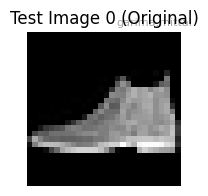

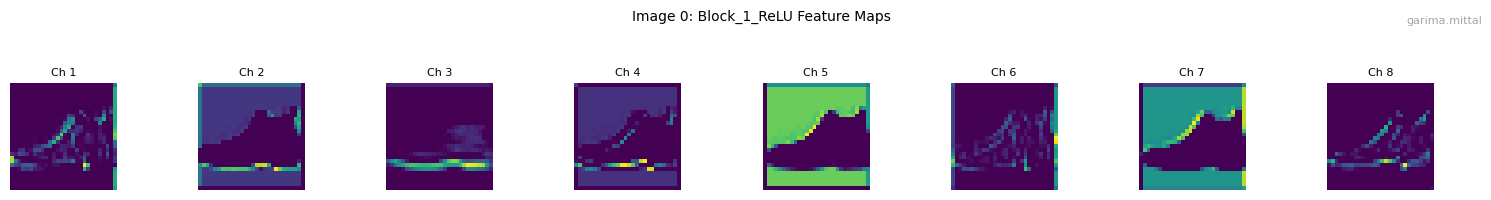

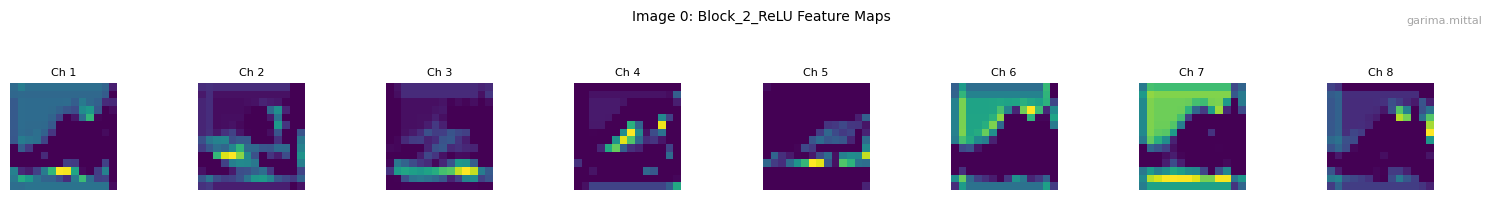

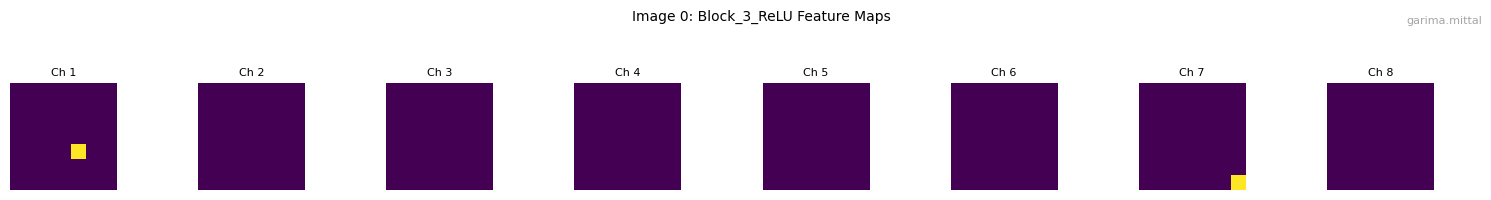

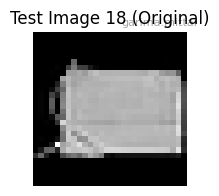

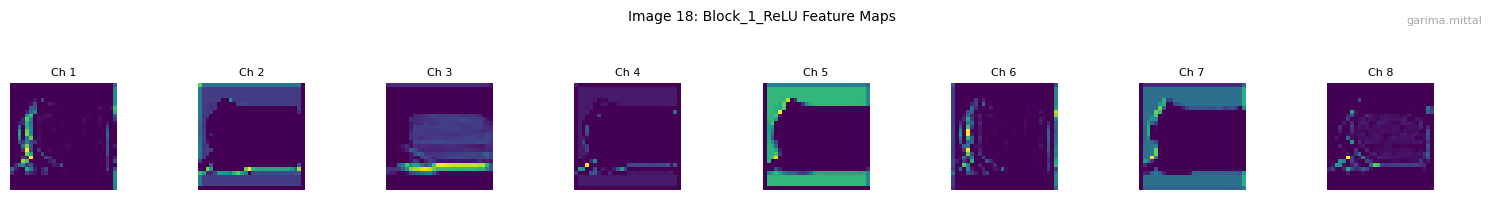

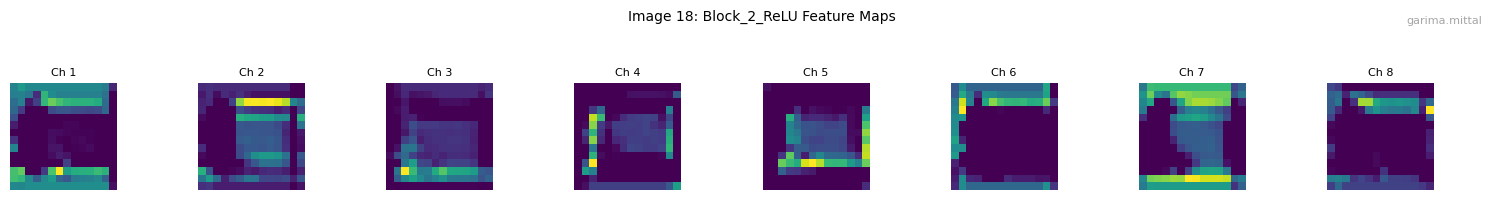

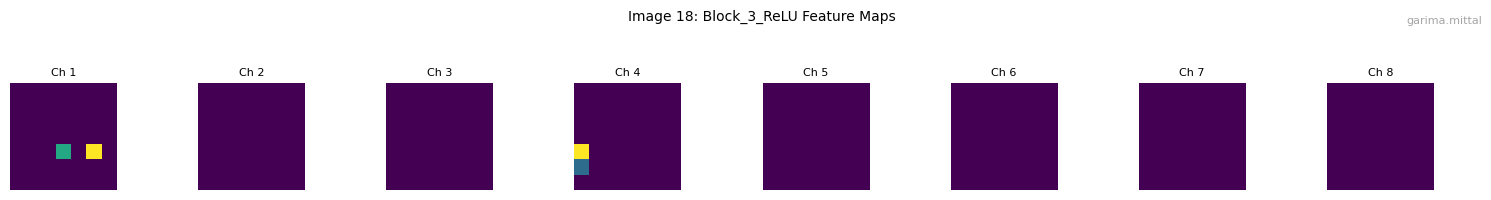

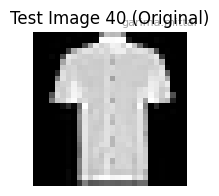

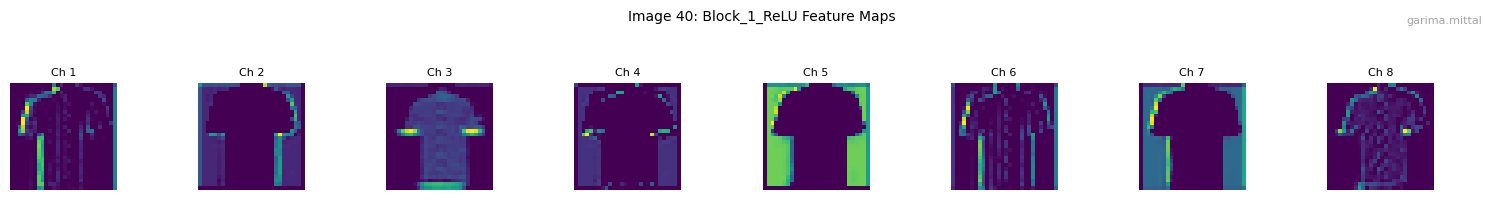

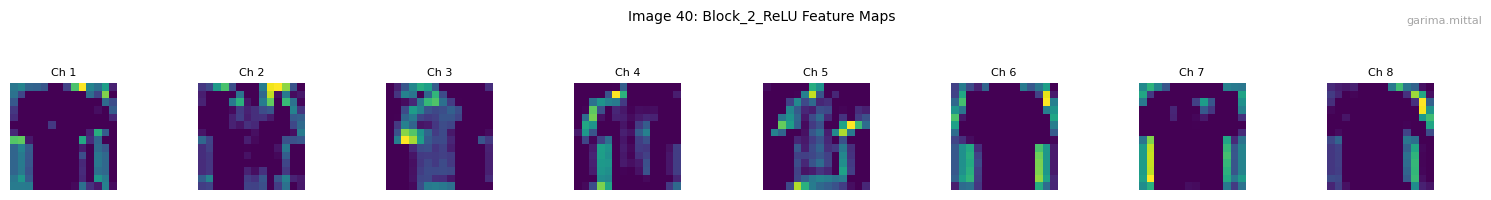

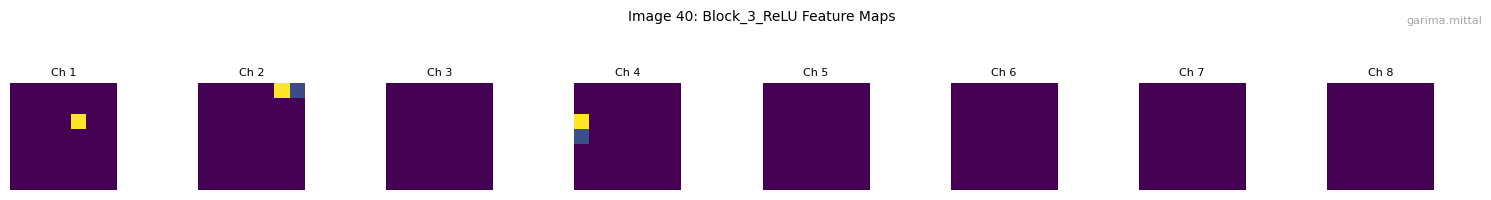

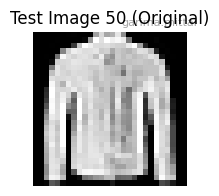

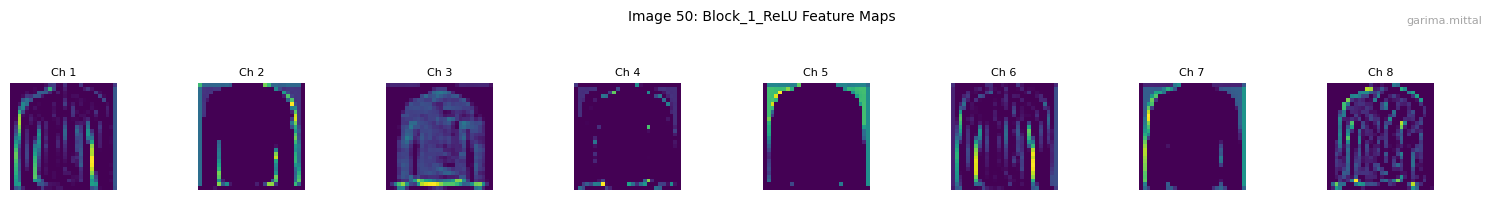

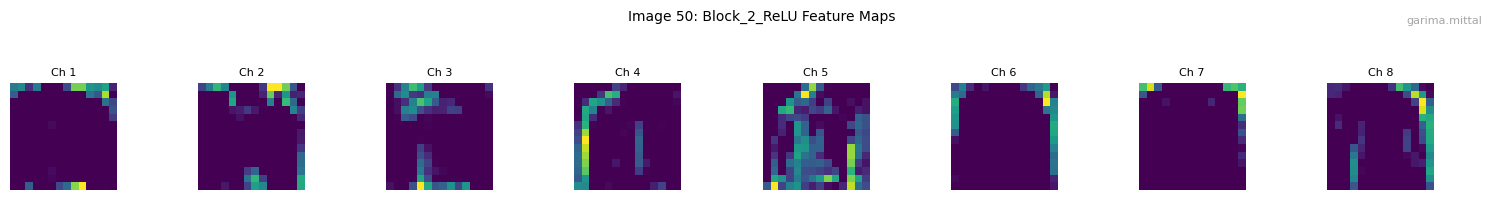

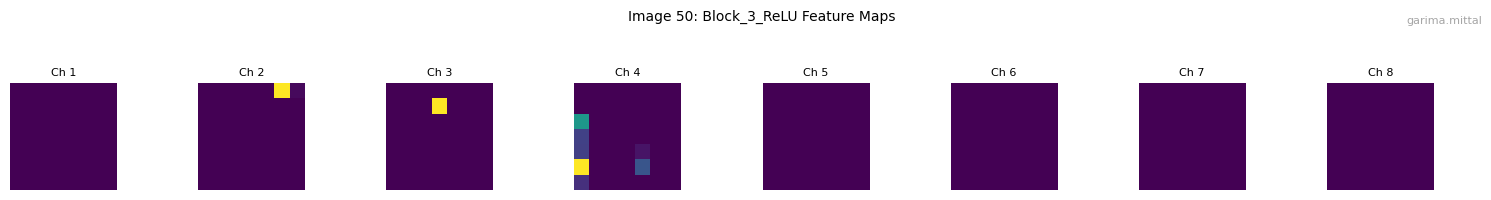

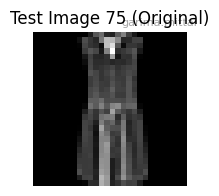

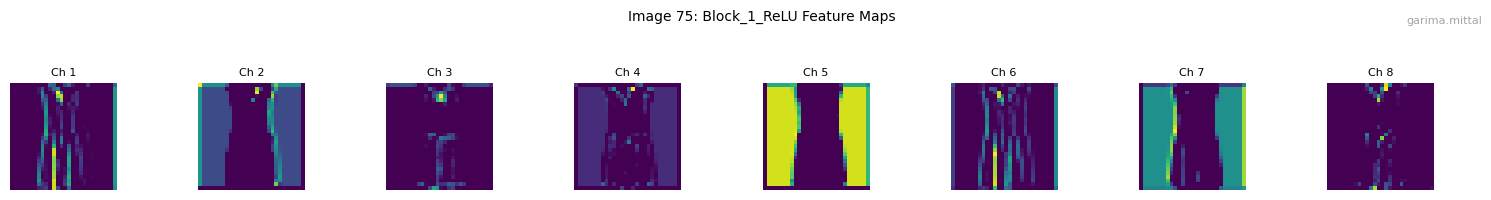

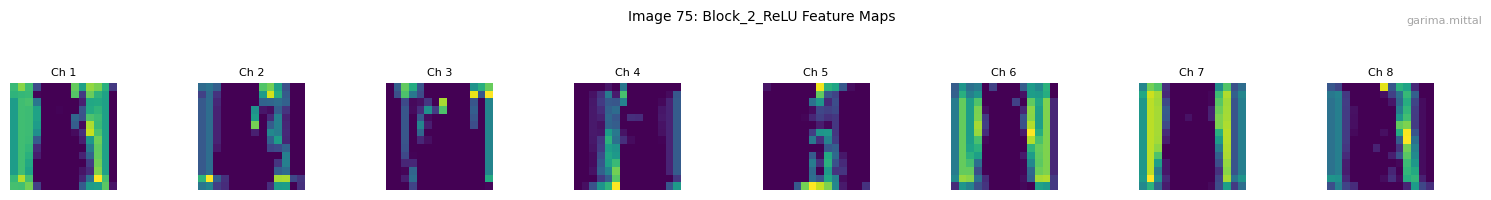

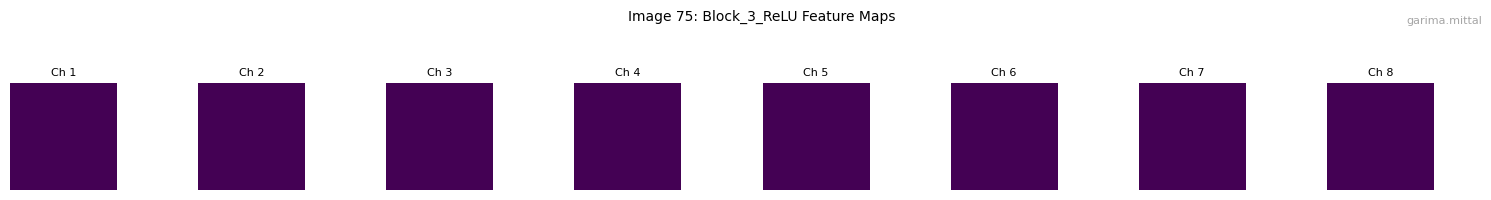

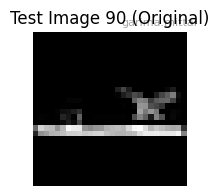

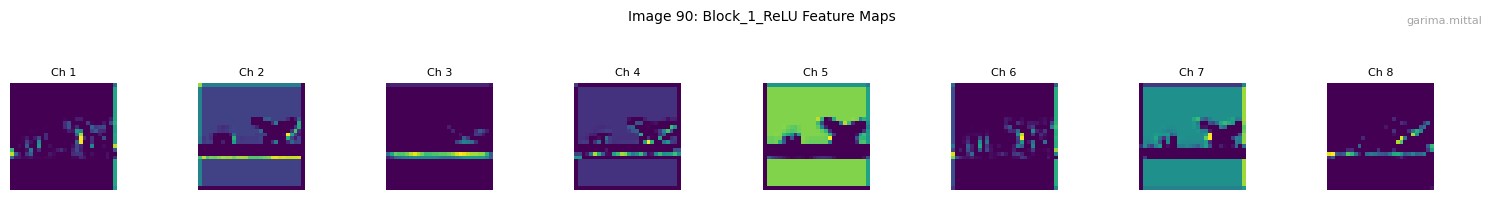

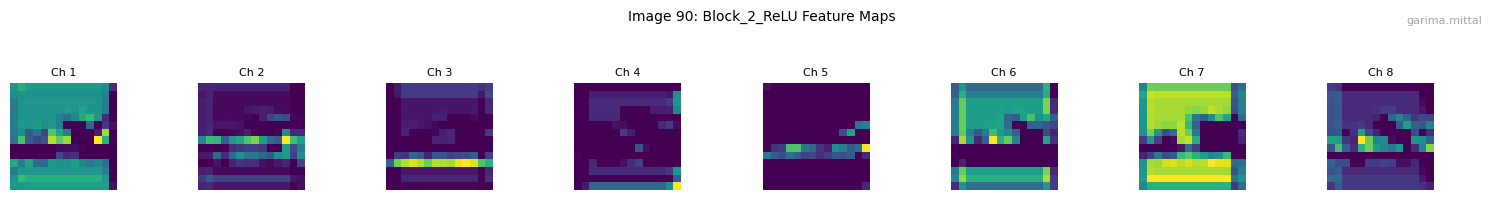

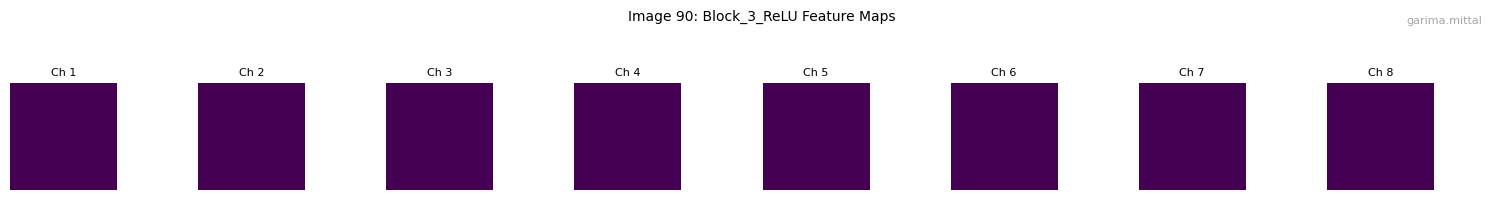

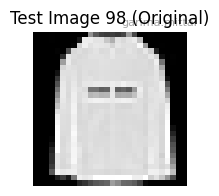

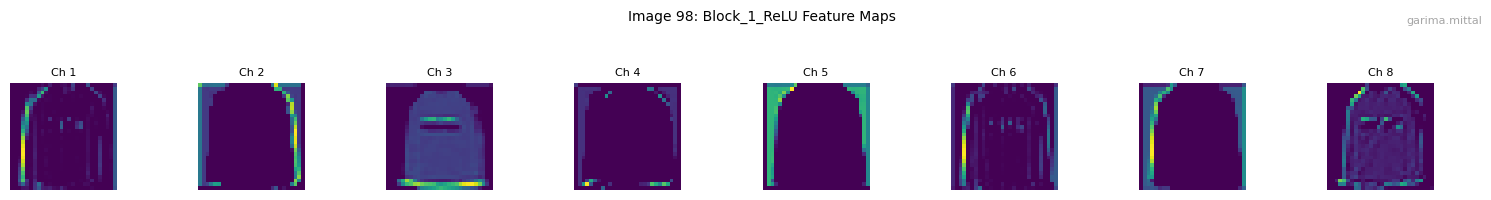

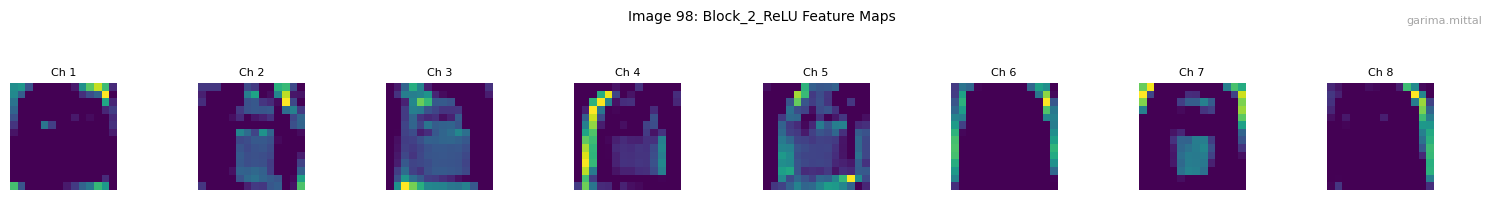

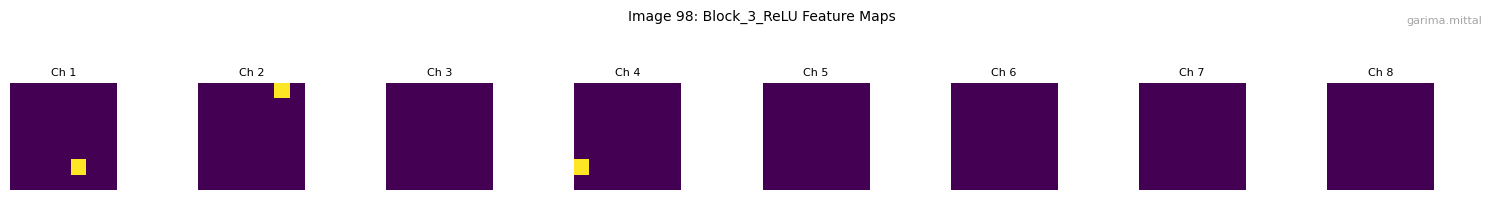

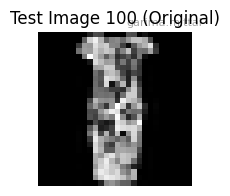

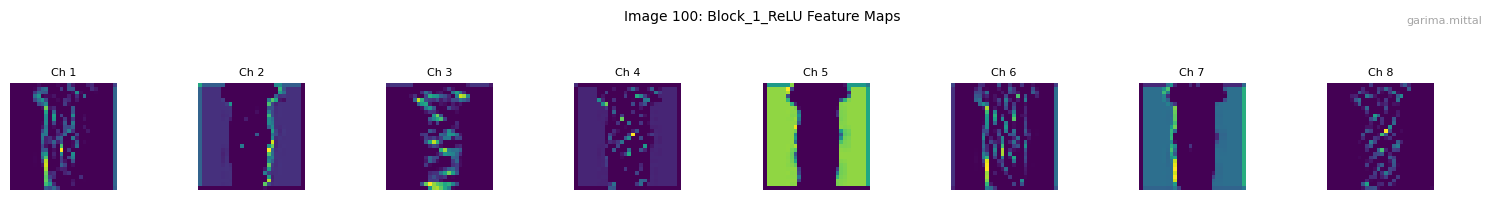

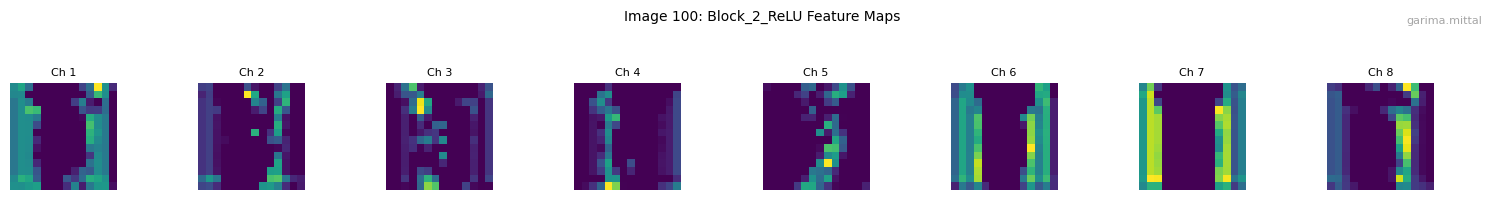

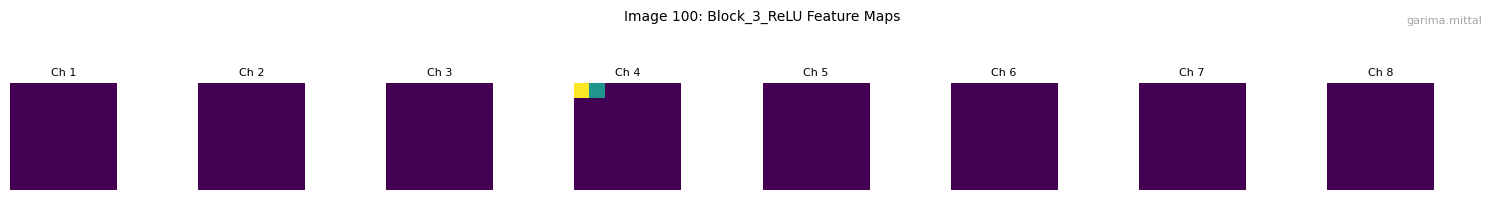

In [23]:
# --- Feature Map Visualization ---
if __name__ == '__main__':    
    model_vis = MultiTaskCNN(dropout_rate=best_acc_run['config']['dropout_rate']).to(DEVICE)
    model_vis.load_state_dict(torch.load(best_acc_run['best_acc_path'], map_location=DEVICE))
    
    vis_indices = [0, 18, 40, 50, 75, 90, 98, 100] # Three test images
    visualize_feature_maps(model_vis, test_dataset, vis_indices, EMAIL_USERNAME)

# Statistical Methods in AI - Assignment 4, Q1 Project Report (PDF Content)

## 🎓 Q1: Multi-Task CNN on Fashion-MNIST

| Student Name | Email Username | Date |
| :--- | :--- | :--- |
| Garima Mittal | `garima.mittal` | November 3, 2025 |

### Deliverables Summary

* **wandb Dashboard Link:** **https://wandb.ai/garimamittal643-international-institute-of-information-t/SMAI_A4_MultiTaskCNN**

---

## 1. Approach and Implementation

### 1.1 Objective and Joint Loss Function

The primary goal of this task was to develop a single Convolutional Neural Network (CNN) capable of simultaneously performing:
1.  **Classification** (10 classes).
2.  **Regression** (predicting the continuous "ink" value, or normalized average pixel intensity).

The training utilized a joint loss function to balance these two objectives:
$$\mathcal{L}_{\text{total}}=\lambda_{1}\mathcal{L}_{\text{CE}}+\lambda_{2}\mathcal{L}_{\text{MSE}}$$
where $\mathcal{L}_{\text{CE}}$ is the Cross-Entropy loss for classification and $\mathcal{L}_{\text{MSE}}$ is the Mean Squared Error loss for regression. The variation of the weighting factors $\lambda_1$ and $\lambda_2$ was critical to exploring the performance trade-off.

---

## 2. Hyperparameter Tuning and Results

A targeted hyperparameter exploration was conducted over five distinct runs, primarily focusing on the weighting factors $\lambda_1$ and $\lambda_2$ and optimizer choice. All runs used a batch size of 128 and trained for 15 epochs.

### 2.1 Hyperparameter Configurations

| Run Name | Optimizer | Learning Rate | Dropout Rate | $\lambda_1$ (CE) | $\lambda_2$ (MSE) | Primary Focus |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Run\_1\_Baseline\_1:1** | Adam | 1e-3 | 0.3 | 1.0 | 1.0 | Balanced |
| **Run\_2\_Cls\_Weighted\_2:1** | Adam | 1e-3 | 0.3 | 2.0 | 1.0 | Classification |
| **Run\_3\_Reg\_Weighted\_1:2** | Adam | 1e-3 | 0.3 | 1.0 | 2.0 | Regression |
| **Run\_4\_SGD\_LowLR\_1:1** | SGD | 1e-4 | 0.3 | 1.0 | 1.0 | Optimizer/LR |
| **Run\_5\_High\_Dropout\_0.5** | Adam | 1e-3 | 0.5 | 1.0 | 1.0 | Regularization |

### 2.2 wandb Logging Confirmation
The `train_and_validate` and `evaluate_on_test` functions ensured all mandatory logging was completed:
* **Configuration:** All hyperparameters ($\lambda_1, \lambda_2$, LR, etc.) were logged.
* **Loss Curves:** Training and validation loss curves ($\mathcal{L}_{\text{total}}$, $\mathcal{L}_{\text{CE}}$, $\mathcal{L}_{\text{MSE}}$) were logged per epoch.
* **Validation Metrics:** Validation Accuracy, MAE, and RMSE were tracked per epoch for model selection.
* **Final Test Performance:** Final metrics for the selected models were logged.


---

## 3. Model Selection and Trade-off Analysis

### 3.1 Model Selection Metrics

Model selection identified the best performing models based on validation metrics, and their final results were evaluated on the test set.

| Selection Criterion | Best Run Name | $\lambda_1$ (CE) | $\lambda_2$ (MSE) | Val. Accuracy | Val. RMSE | **Test Accuracy** | **Test MAE** | **Test RMSE** |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Highest Val. Accuracy** | **Run\_2\_Cls\_Weighted\_2:1** | **2.0** | **1.0** | 0.89833 | 0.0252 | **0.8977** | **0.03034** | **0.03952** |
| **Lowest Val. RMSE** | **Run\_3\_Reg\_Weighted\_1:2** | **1.0** | **2.0** | 0.89733 | **0.02413** | **0.8547** | **0.01911** | **0.02432** |

*(Note: Validation metrics are the best logged summary values, Test Metrics are the final printout results.)*

### 3.2 Discussion on $\lambda_1, \lambda_2$ Trade-off

The two runs focused on adjusting $\lambda_1$ and $\lambda_2$ (Run 2 and Run 3) provide clear evidence of the multi-task trade-off:

1.  **Classification Priority ($\lambda_1=2.0, \lambda_2=1.0$):**
    * The model prioritized classification loss, leading to the best **Test Accuracy (0.8977)** observed across the runs.
    * **Trade-off:** This focus resulted in a relatively high **Test RMSE (0.03952)**. The shared backbone features became highly tuned to class-specific boundaries (e.g., shoe vs. shirt), sacrificing precision in capturing the simple scalar average intensity.

2.  **Regression Priority ($\lambda_1=1.0, \lambda_2=2.0$):**
    * The model heavily prioritized regression loss, successfully minimizing the error in predicting the average pixel intensity, leading to the lowest **Test RMSE (0.02432)** and **Test MAE (0.01911)**.
    * **Trade-off:** While excellent for regression, the focus on intensity averages slightly reduced its ability to differentiate fine-grained classification features, resulting in a noticeable **drop in Test Accuracy (0.8547)** compared to the classification-weighted run.

**Conclusion:** The $\lambda$ factors successfully modulated the influence of each gradient, forcing the shared features to compromise. A higher $\lambda_2$ leads to superior regression performance at the cost of classification accuracy, and vice-versa, demonstrating a critical engineering decision required in deploying multi-task models.

---

## 4. Feature Map Visualization and Interpretation

### 4.1 Feature Map Placement

Intermediate feature maps were extracted using **PyTorch hooks** registered after the `ReLU` activation in each convolutional block (Block 1, Block 2, and Block 3). The chosen model for visualization was the **Highest Validation Accuracy Model (Run 2: $\lambda_1=2.0$)**.


### 4.2 Interpretation of Features

| Layer Depth | Kinds of Features Captured | Contribution to Classification (Fashion Category) | Contribution to Ink Regression (Average Pixel Value) |
| :--- | :--- | :--- | :--- |
| **Early Layers (Block 1)** | **Edges, Corners, Simple Textures.** Local and high-resolution features. | Crucial for establishing the **gross boundary and shape** of the garment, quickly separating foreground from background. | Captures **local pixel intensity** and small texture variations, forming the basis for the global average calculation. |
| **Intermediate Layers (Block 2)** | **Mid-Level Components, Structured Patterns.** Integration of local features over a wider receptive field. | Identifies **characteristic parts** (e.g., sleeves, zippers, shoe components), which are key discriminators for classes like 'Pullover' vs. 'T-shirt'. | Provides a **spatially reduced map of regional luminance**. Helps segment large blocks of dark pixels from light pixels for more accurate regional averaging. |
| **Deep Layers (Block 3 / Input to Heads)** | **Abstract/Semantic Features, Object Identity.** Global and highly processed features. | Encodes the **final semantic concept** (e.g., "Trouser" or "Bag"). This compressed representation is directly fed to the classification head for decision-making. | Captures the **overall brightness and density** of the entire object, robust to fine noise. This summary feature is optimal for predicting the single scalar "ink" target. |

All the line charts are in the wandb dashboard and the visualisations are in the above cell